# XBTorch::Example 09:Gradient Decomposition Methods

## Introduction

In this example, we will explore various gradient decomposition methods that can be applied when training neural networks in XBTorch. This feature can be used with or without HWA training. The concept of gradient decomposition methods, and why it's important when training memristive neural networks, is elaborated in [1]. Here, we train a two-layer perceptron network on the MNIST dataset using the Streaming Batch Principal Component Analysis (SBPCA) gradient decomposition method from [2], an implementation of which is provided by XBTorch out-of-the-box (among other such algorithms), and a tabular FeFET device model. We will compare the training performance of networks across various algorithmic hyperparameters. We will not utilize WAGE quantization for simplicity, but that could be added following the examples presented in HWA training notebooks. 

## Getting Started

Let's import necessary dependencies.

In [1]:
# General Imports
import numpy as np
import matplotlib.pyplot as plt
import random
import time
from pathlib import Path
import os
import pickle

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [2]:
# XBTorch Imports
import xbtorch
import xbtorch.optim as xboptim
from xbtorch.patches import xbtorch_model
from xbtorch.devices import TabularCompactFeFETKriging
from xbtorch.nn.utils import test_classifier, train_classifier
from xbtorch.decomposition import SBPCA, NMF # this example uses SBPCA, but feel free to swap out for NMF or some other method

from nets.mlp import SimpleMLP

W1001 09:27:48.344000 2891160 torch/utils/cpp_extension.py:2425] TORCH_CUDA_ARCH_LIST is not set, all archs for visible cards are included for compilation. 
W1001 09:27:48.344000 2891160 torch/utils/cpp_extension.py:2425] If this is not desired, please set os.environ['TORCH_CUDA_ARCH_LIST'] to specific architectures.


In [3]:
seed = 0

torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed) # controls weight updatejump table stochasticity

# Check if CUDA is available and select the device
device = torch.device("cuda:4" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:4


## Prepare the dataset

We can now prepare the dataset for our neural network. For simplicity, we will stick to the MNIST dataset for this example.

In [4]:
# Define transforms to apply to the data
transform = transforms.Compose([
    transforms.ToTensor(),  # Convert images to tensors
    transforms.Normalize((0.1307,), (0.3081,))  # Normalize the image data
])

# Load the MNIST training and test datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Create data loaders for batching and shuffling
train_loader = DataLoader(train_dataset, batch_size=4096, shuffle=True, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=10000, shuffle=False, num_workers=4)

## Network Parameters

We will work with a simple 2-layer perceptron network. Example network implementations are provided in the `nets/` directory.

In [5]:
# Define the model
input_size = 28 * 28
hidden_size = 150
output_size = 10

epochs = 20
lr = 0.1 # could be sweeped for each rank
iterations = 10

criterion = nn.CrossEntropyLoss()

## Initialize XBTorch

In [6]:
xb_device_model = "tab_fefet_compact_vgs_0.9_sd_5" # device model name goes here
xb_device = TabularCompactFeFETKriging(xb_device_model)

## Gradient Decomposition Algorithms

The XBTorch module that handles gradient decomposition methods is the `GenericDecomposition` primitive defined in the `xbtorch.decomposition` module. XBTorch supports the following gradient decomposition algorithms, or presets, out-of-the-box. 

| Decomposition Algorithm    | XBTorch Module |
| -------- | ------- |
| Full-rank singular value decomposition   | `FullSVD`   |
| Low-rank singular value decomposition |  `TruncatedSVD`    |
| Non-negative matrix factorization   | `NMF`    |
| Streaming batch principal component analysis    | `SBPCA` |
| Full-rank outer product (equivalent to no decomposition)    | `FullOuterProduct` |

See the full API for further details on each. Custom presets can be created by inheriting from the `GenericDecomposition` primitive. For this example, we will be focusing solely on streaming batch principal component analysis (SBPCA), but the analysis can be extended for all.

In [7]:
ranks = [1, 2, 4]

In [8]:
rank_loss = np.zeros((len(ranks), iterations, epochs))
rank_accs = np.zeros((len(ranks), iterations, epochs))

for rank_idx, rank in enumerate(ranks):
    for iteration in range(iterations):
        decomposition_algorithm = SBPCA(rank=rank)
    
        xbtorch.initialize(device_type=xb_device,
                           pytorch_device=device,
                           decomposition_algorithm=decomposition_algorithm
                           )
    
        model = SimpleMLP(input_size, hidden_size, output_size).to(device)
        model = xbtorch_model(model)
        
        optimizer = xboptim.SGD(model.parameters(), lr=lr)
    
        for epoch in range(epochs):
            loss = train_classifier(train_loader, model, criterion, optimizer, epoch, epochs, device)
            accuracy, _ = test_classifier(test_loader, model, device)
    
            rank_loss[rank_idx, iteration, epoch] = loss
            rank_accs[rank_idx, iteration, epoch] = accuracy

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


In [9]:
rank_accs_losss_dict = {"accs": rank_accs,
                        "losss": rank_loss}

# Save statistics for plotting later, if necessary (can be skipped)
output_path = "checkpoints/"
Path(output_path).mkdir(parents=False, exist_ok=True)
model_name = f"{output_path}/gradient_decomp_sbpca_{xb_device_model}_example.pkl"
with open(model_name, "wb") as f:
    pickle.dump(rank_accs_losss_dict, f)

In [10]:
# Load statistics dumped prior
with open(f"checkpoints/gradient_decomp_sbpca_{xb_device_model}_example.pkl", "rb") as f:
    rank_accs_losss_dict = pickle.load(f)

In [11]:
def plot_network_performance(xs, ys, x_label, y_label, legend_texts=None):
    # plot average responses
    plt.figure()
    
    for i in range(len(ys)): 
        plt.plot(xs, 
                 np.average(ys[i], axis=0),
                 label=legend_texts[i])

    plt.legend()
    plt.xlabel(x_label)
    plt.ylabel(y_label)

In [12]:
xs = list(range(1, epochs+1))

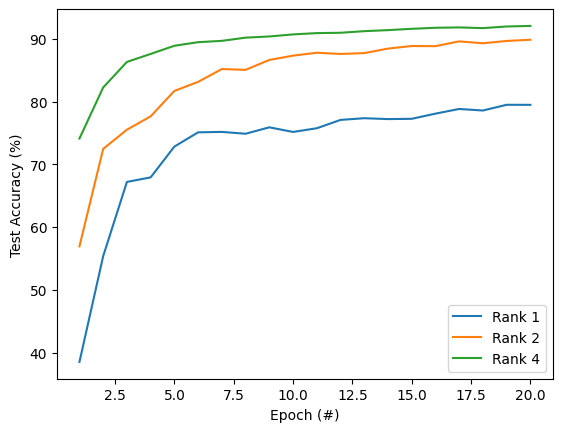

In [13]:
# Plot test accuracies
plot_network_performance(xs, rank_accs_losss_dict["accs"], "Epoch (#)", "Test Accuracy (%)", legend_texts=[f"Rank {i}" for i in ranks])

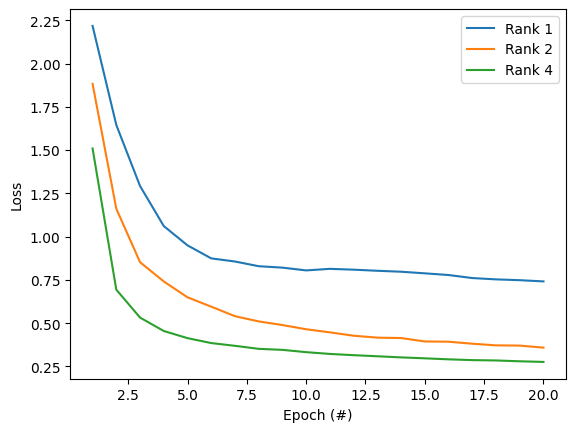

In [14]:
# Plot train losss
plot_network_performance(xs, rank_accs_losss_dict["losss"], "Epoch (#)", "Loss", legend_texts=[f"Rank {i}" for i in ranks])

## Conclusion

We saw how XBTorch device models could be paired with gradient decomposition methods. These methods directly apply transformations to the underlying gradient matrix before parameter updates. When a device model is specified, the decomposed gradient matrix is converted to pulse information for conductance updates. If one is interested in exploring the impact of a gradient decomposition method without a device model, that is also possible. In such case, the decomposed gradient matrix is directly used to update network parameters. One could also pair gradient decomposition methods with the hardware-aware training capabilities provided by XBTorch.

## References

1. Zhao, J., Huang, S., Yousuf, O., Gao, Y., Hoskins, B. D., & Adam, G. C. (2021). Gradient decomposition methods for training neural networks with non-ideal synaptic devices. Frontiers in Neuroscience, 15, 749811.
2. Hoskins, B. D., Daniels, M. W., Huang, S., Madhavan, A., Adam, G. C., Zhitenev, N., ... & Stiles, M. D. (2019). Streaming batch eigenupdates for hardware neural networks. Frontiers in neuroscience, 13, 793.